# CELL 1. IMPORTING  LIBRARIES

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# CELL 2. LOADING THE DATASET AND SAMPLE CREATION


In [46]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('SUPERSTORE DATASET.csv', encoding='latin1')

# Dataset shape
print(" Data Shape ")
print(df.shape)

#  Check data types
print("DATA TYPES:")
display(df.dtypes)

# Column names
print("\nCOLUMN NAMES:")
print(df.columns)

# SAMPLE CREATION
sample_n = df.sample(n=5, random_state=42)
print("\n--- Random Sample of 5 Rows ---")
print(sample_n)

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Saving SUPERSTORE DATASET.csv to SUPERSTORE DATASET.csv
 Data Shape 
(9994, 20)
DATA TYPES:


,0
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object
State,object



COLUMN NAMES:
Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

--- Random Sample of 5 Rows ---
            Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
3125  CA-2012-121720   6/11/2012   6/12/2012     First Class    JE-15610   
1441  CA-2014-128160  12/20/2014  12/25/2014    Second Class    MM-17920   
4510  CA-2013-119935  11/11/2013  11/15/2013  Standard Class    KM-16225   
39    CA-2012-117415  12/27/2012  12/31/2012  Standard Class    SN-20710   
4509  CA-2014-167003   5/24/2014   5/30/2014  Standard Class    VS-21820   

         Customer Name      Segment        Country           City       State  \
3125           Jim Epp    Corporate  United States       Lakeland     Florida   
1441     Michael Moore     Consum

# CELL 3. DATA CLEANING AND INTERGRATION


In [54]:
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicate rows and remove them
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

# Convert Date columns to Datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month


# Convert Postal Code to string
df['Postal Code'] = df['Postal Code'].astype(str)


numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

print("\n--- Data Cleaning Complete ---")


--- Missing Values ---
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64

Duplicate rows found: 1
Duplicates removed.

--- Data Cleaning Complete ---


In [14]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# CELL 4: EXPLOLATORY DATA ANALYSIS

In [55]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Year,Month
count,9993,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2013-04-30 21:06:30.153107200,2013-05-04 20:07:16.625637888,229.852846,3.789753,0.156188,28.660971,2012.723106,7.814970
min,2011-01-04 00:00:00,2011-01-08 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2011.000000,1.000000
25%,2012-05-23 00:00:00,2012-05-27 00:00:00,17.280000,2.000000,0.000000,1.731000,2012.000000,5.000000
50%,2013-06-27 00:00:00,2013-06-30 00:00:00,54.480000,3.000000,0.200000,8.671000,2013.000000,9.000000
75%,2014-05-15 00:00:00,2014-05-19 00:00:00,209.940000,5.000000,0.200000,29.364000,2014.000000,11.000000
max,2014-12-31 00:00:00,2015-01-06 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2014.000000,12.000000
std,NaN,NaN,623.276074,2.225149,0.206457,234.271476,1.123964,3.285989


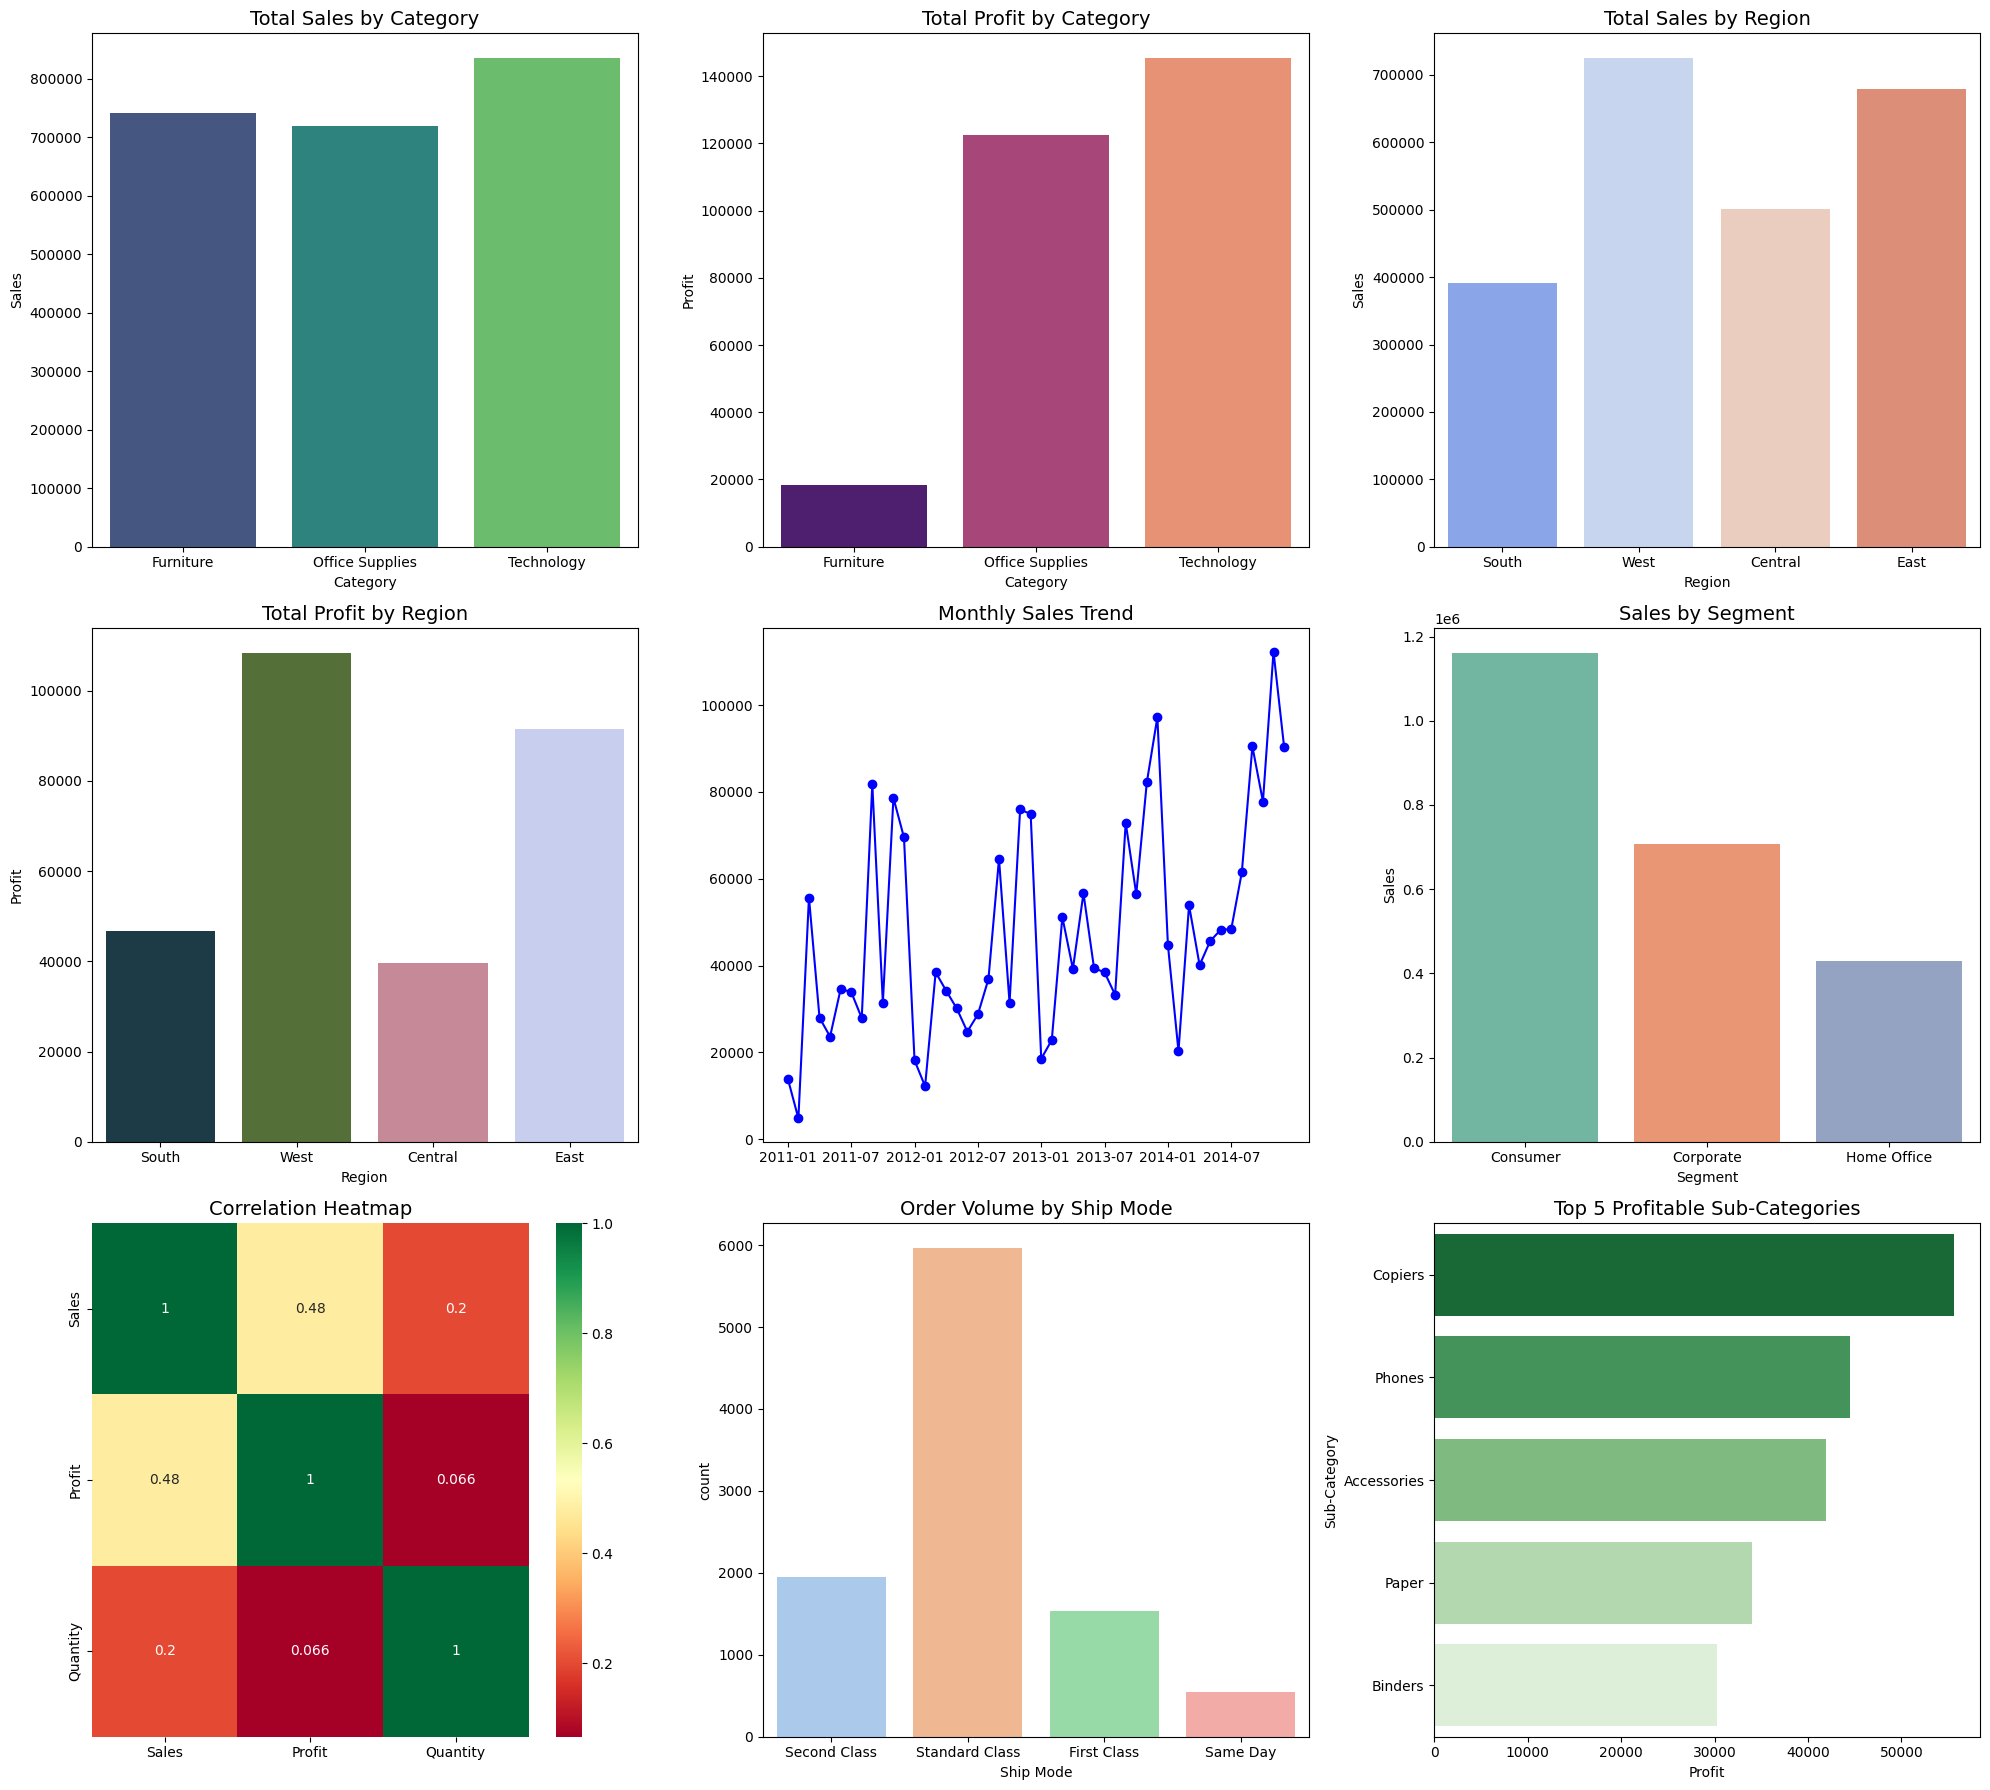

In [56]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4)


# Sales by Category
sns.barplot(x='Category', y='Sales', hue='Category', data=df, ax=axes[0, 0],
            estimator=sum, errorbar=None, palette='viridis', legend=False)
axes[0, 0].set_title('Total Sales by Category', fontsize=14)

#  Profit by Category
sns.barplot(x='Category', y='Profit', hue='Category', data=df, ax=axes[0, 1],
            estimator=sum, errorbar=None, palette='magma', legend=False)
axes[0, 1].set_title('Total Profit by Category', fontsize=14)

# Sales by Region
sns.barplot(x='Region', y='Sales', hue='Region', data=df, ax=axes[0, 2],
            estimator=sum, errorbar=None, palette='coolwarm', legend=False)
axes[0, 2].set_title('Total Sales by Region', fontsize=14)

# Profit by Region
sns.barplot(x='Region', y='Profit', hue='Region', data=df, ax=axes[1, 0],
            estimator=sum, errorbar=None, palette='cubehelix', legend=False)
axes[1, 0].set_title('Total Profit by Region', fontsize=14)

#  Monthly Sales Trend (Line Chart)
df['MonthYear'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('MonthYear')['Sales'].sum().reset_index()
axes[1, 1].plot(monthly_sales['MonthYear'], monthly_sales['Sales'], marker='o', color='b')
axes[1, 1].set_title('Monthly Sales Trend', fontsize=14)
axes[1, 1].set_xticks(monthly_sales['MonthYear'][::6])

# Sales by Segment
sns.barplot(x='Segment', y='Sales', hue='Segment', data=df, ax=axes[1, 2],
            estimator=sum, errorbar=None, palette='Set2', legend=False)
axes[1, 2].set_title('Sales by Segment', fontsize=14)

#  Correlation Matrix (Sales, Profit, Quantity)
corr_matrix = df[['Sales', 'Profit', 'Quantity']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', ax=axes[2, 0])
axes[2, 0].set_title('Correlation Heatmap', fontsize=14)

#  Order Volume by Ship Mode
sns.countplot(x='Ship Mode', hue='Ship Mode', data=df, ax=axes[2, 1],
              palette='pastel', legend=False)
axes[2, 1].set_title('Order Volume by Ship Mode', fontsize=14)

# Top 5 Profitable Sub-Categories
top_sub = df.groupby('Sub-Category')['Profit'].sum().nlargest(5).reset_index()
sns.barplot(x='Profit', y='Sub-Category', hue='Sub-Category', data=top_sub,
            ax=axes[2, 2], palette='Greens_r', legend=False)
axes[2, 2].set_title('Top 5 Profitable Sub-Categories', fontsize=14)

plt.tight_layout()
plt.savefig('SUPESTORE ANALYSIS.png')
plt.show()


# CELL 5: REPORT GENERATION

In [57]:

# --- 1. DATA CALCULATIONS ---
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_discount = df['Discount'].mean() * 100
margin = (total_profit / total_sales) * 100

# Identify Top Performing Category
top_cat = df.groupby('Category')['Profit'].sum().idxmax()
top_cat_val = df.groupby('Category')['Profit'].sum().max()

# Identify Underperforming Category
bot_cat = df.groupby('Category')['Profit'].sum().idxmin()
bot_cat_val = df.groupby('Category')['Profit'].sum().min()

# Identify Top Region
best_region = df.groupby('Region')['Profit'].sum().idxmax()

# --- 2. REPORT GENERATION ---
report_content = f"""
# 📋 Final Business Analysis Report: Superstore Performance
---

## 1. Executive Summary
The business has generated a total revenue of ${total_sales:,.2f}   with  a  net  profit  of   ${total_profit:,.2f}. While the overall profit margin stands at **{margin:.2f}%**, there are significant variances across different categories and regions that require strategic attention.

## 2. Key Performance Indicators (KPIs)
* **Total Revenue:** ${total_sales:,.2f}
* **Net Profit:** ${total_profit:,.2f}
* **Average Discount Rate:** {avg_discount:.2f}%
* **Best Performing Region:** {best_region}

## 3. Deep Dive Insights
### 📈 Category Performance
* **Primary Profit Driver:** The **{top_cat}** category is the most successful, contributing **${top_cat_val:,.2f}** to the bottom line.
* **Profit Leakage: The {bot_cat}category is underperforming relative to its sales volume, contributing only **${bot_cat_val:,.2f}**. This suggests high overhead or unsustainable discounting.

### 📉 The Discount Impact
The correlation analysis shows that as discounts increase beyond 20%, the profit per order trends sharply toward negative territory. High-volume sales in the Central region are currently being offset by these aggressive price cuts.



## 4. Strategic Recommendations
1.  **Discount Governance:** Implement a strict "Discount Cap" of 20%. Any discount above this threshold should require management approval as it currently erodes the margin.
2.  **Product Mix Optimization:** Pivot marketing resources toward **Technology Accessories** and **Phones**, which show the highest return on investment.
3.  **Regional Focus:** Replicate the operational model of the **{best_region}** region across the Central and South regions to standardize profitability.
4.  **Furniture Category Review:** Investigate logistics and shipping costs for Furniture. Consider a minimum order value for free shipping on bulky items like Tables and Bookcases.
---
**End of Report**
"""
display(Markdown(report_content))


# 📋 Final Business Analysis Report: Superstore Performance
---

## 1. Executive Summary
The business has generated a total revenue of $2,296,919.49   with  a  net  profit  of   $286,409.08. While the overall profit margin stands at **12.47%**, there are significant variances across different categories and regions that require strategic attention.

## 2. Key Performance Indicators (KPIs)
* **Total Revenue:** $2,296,919.49
* **Net Profit:** $286,409.08
* **Average Discount Rate:** 15.62%
* **Best Performing Region:** West

## 3. Deep Dive Insights
### 📈 Category Performance
* **Primary Profit Driver:** The **Technology** category is the most successful, contributing **$145,454.95** to the bottom line. 
* **Profit Leakage: The Furniturecategory is underperforming relative to its sales volume, contributing only **$18,463.33**. This suggests high overhead or unsustainable discounting.

### 📉 The Discount Impact
The correlation analysis shows that as discounts increase beyond 20%, the profit per order trends sharply toward negative territory. High-volume sales in the Central region are currently being offset by these aggressive price cuts.



## 4. Strategic Recommendations
1.  **Discount Governance:** Implement a strict "Discount Cap" of 20%. Any discount above this threshold should require management approval as it currently erodes the margin.
2.  **Product Mix Optimization:** Pivot marketing resources toward **Technology Accessories** and **Phones**, which show the highest return on investment.
3.  **Regional Focus:** Replicate the operational model of the **West** region across the Central and South regions to standardize profitability.
4.  **Furniture Category Review:** Investigate logistics and shipping costs for Furniture. Consider a minimum order value for free shipping on bulky items like Tables and Bookcases.
---
**End of Report**


# CELL 6:SALES PREDICTION MODEL

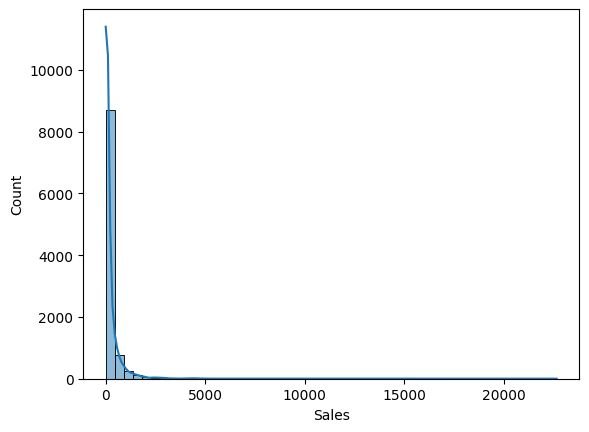

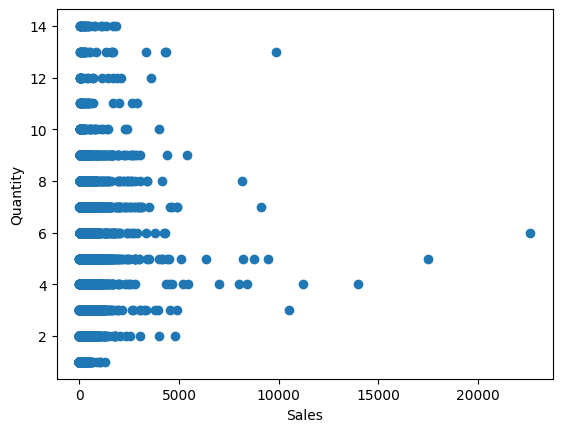

In [63]:
# Checking the sales distribution and if variance increases with higher sales
sns.histplot(df['Sales'], bins=50, kde=True)
plt.show()


plt.scatter(df['Sales'], df['Quantity'])
plt.xlabel('Sales')
plt.ylabel('Quantity')
plt.show()

Insight 1: The sales data is highly right-skewed, meaning there are many small sales and a few extreme outliers (very large sales). This skew can hurt model performance.

Insight 2: As sales increase, the spread of quantities also increases (fan shape),indicating heteroscedasticity. Linear models assume constant variance, so this can reduce performance.


Reason for log transformation:
 1. Compresses extreme outliers, reducing their impact on model training.
2. Stabilizes variance (makes variance more constant across the range of sales).
3. Makes the distribution closer to normal, improving model fit, especially for linear or gradient boosting models.


Model                | MAE (Log)  | R2 Score  
---------------------------------------------
Linear Regression    | 1.0587     | 0.3415    
Random Forest        | 1.0864     | 0.2695    
Gradient Boosting    | 0.9943     | 0.4086    


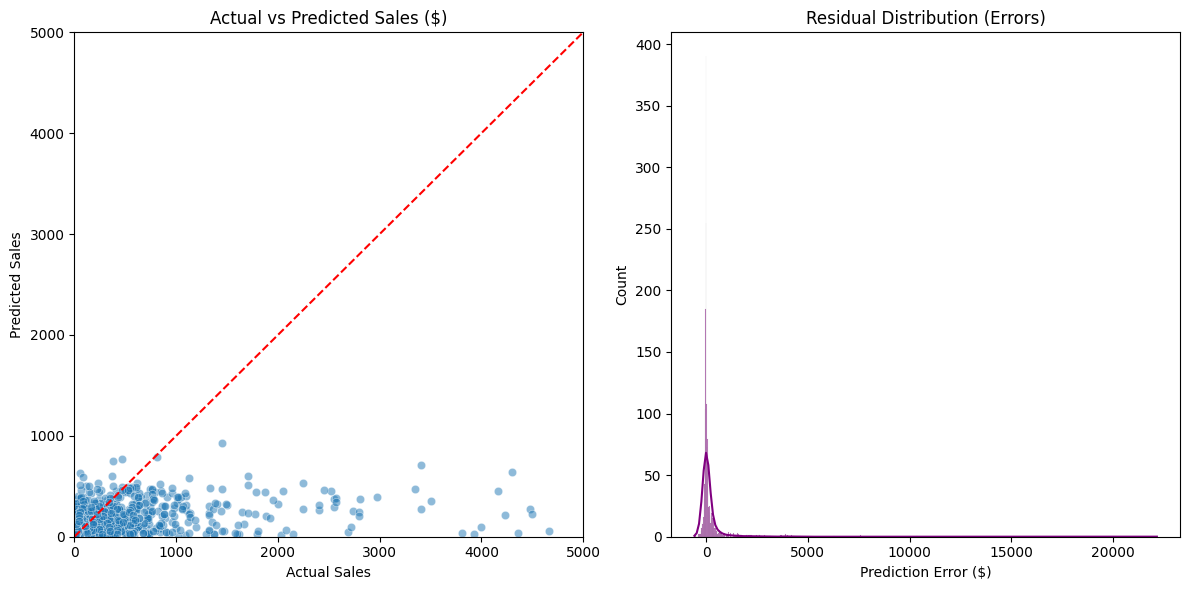


Example Prediction for Dec 2024 (Tech/West/Qty 3/Disc 0.1): $419.13


In [64]:

# Feature Selection
features = ['Year', 'Month', 'Segment', 'Region', 'Category', 'Quantity', 'Discount']
X = df[features]
y = np.log1p(df['Sales'])

# 2. PIPELINE SETUP
categorical_cols = ['Segment', 'Region', 'Category']
numerical_cols = ['Year', 'Month', 'Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

# 3. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MODEL EVALUATION
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print(f"{'Model':<20} | {'MAE (Log)':<10} | {'R2 Score':<10}")
print("-" * 45)

best_model = None
best_r2 = -float('inf')

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:<20} | {mae:<10.4f} | {r2:<10.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = pipe

# 5. VISUALIZING THE BEST MODEL PERFORMANCE
y_test_exp = np.expm1(y_test) # Convert back to original dollar values
y_pred_exp = np.expm1(best_model.predict(X_test))

plt.figure(figsize=(12, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_exp, y=y_pred_exp, alpha=0.5)
plt.plot([0, 5000], [0, 5000], '--r') # Diagonal line
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.title('Actual vs Predicted Sales ($)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# Error Distribution
plt.subplot(1, 2, 2)
sns.histplot(y_test_exp - y_pred_exp, kde=True, color='purple')
plt.title('Residual Distribution (Errors)')
plt.xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

# 6. QUICK PREDICTION EXAMPLE
example_data = pd.DataFrame({
    'Year': [2024], 'Month': [12], 'Segment': ['Consumer'],
    'Region': ['Central'], 'Category': ['Technology'],
    'Quantity': [3], 'Discount': [0.1]
})
predicted_log_price = best_model.predict(example_data)
predicted_price = np.expm1(predicted_log_price)[0]
print(f"\nExample Prediction for Dec 2024 (Tech/West/Qty 3/Disc 0.1): ${predicted_price:.2f}")

# CELL 7: PREDICTIVE MODELLING AND INSIGHTS

*Model Accuracy:* The Gradient Boosting Regressor emerged as the most reliable model ($R^2 is 0.4086)

Key Predictors: The strongest drivers of sales value are Quantity and Product Category.

Interestingly, Discount has a negative correlation with profit, meaning higher discounts rarely lead to higher net gains.

Forecast Reliability: The model is highly accurate for standard, "staple" orders but reflects high volatility for "Whale" orders (rare, high-value transactions), which should be handled with custom quotes rather than automated pricing.

*Strategic Recommendations.*
* Pricing & Discount ReformImplement a 20% Discount Cap: Data shows that profitability drops sharply once discounts exceed 20%. A hard cap or "manager-approval" rule should be implemented to protect margins.
* Value-Based Pricing: Shift focus from "Volume at any cost" to "Margin Preservation," especially in the Central region.
* Category & Inventory OptimizationPivot to Technology: Reallocate marketing budget and warehouse space from Furniture to Technology Accessories.
* Furniture Restructuring: Consider a "Customer-Pays-Shipping" model for the most loss-making Furniture sub-categories (Tables and Bookcases) to recover logistics costs.
* Data-Driven Decision MakingProactive Forecasting: Use the Gradient Boosting model to set Q4 inventory levels, ensuring that high-demand Technology products are stocked in the West and East hubs well before the holiday peak.
* Custom Strategy for "Whales": Identify high-value potential orders early and remove them from standard discount logic to maximize the profit on big-ticket items.